# Will it rain tomorrow? Predicting Nigerian weather with machine learning

This project uses machine learning to predict two things for four Nigerian cities:

1. **Will it rain tomorrow?** (at least 1 mm of rain)
2. **What will tomorrow's maximum temperature be?**

**Cities:** Lagos, Port Harcourt, Abuja and Kano.

**Data:** Daily weather data from the Open-Meteo historical archive, covering January 2000 to June 2026.

I split the data by time, so the models are trained on older years and tested on later years. I also compare them with simple baselines to see whether the machine learning models actually add anything.

The data is modelled weather data rather than direct weather-station readings, so I don't treat the results as a replacement for a real forecasting system. The main goal is to see what can be predicted from recent weather patterns and how much the models improve on simple approaches.

---
---
## Where everything is

| # | Section | Graphs |
|---|---|---|
| 1 | Setup | none |
| 2 | Getting the data | none |
| 3 | Cleaning | none |
| 4 | Exploring the data | **G1** monthly rainfall, **G2** monthly max temperature, **G3** rainy-day heatmap, **G4** yearly temperature trend, **G5** rain amounts, **G6** correlation heatmap |
| 5 | Building features | none |
| 6 | Splitting by time | **G7** train / validation / test timeline |
| 7 | Baselines | none |
| 8 | Rain model | none |
| 9 | Temperature model | none |
| 10 | Final models (calibrate and retrain) | none |
| 11 | Evaluation | **G8** ROC curves, **G9** confusion matrix, **G10** calibration before and after the fix, **G11** each city vs its own baseline, **G12** actual vs predicted temperature, **G13** temperature error by city and month, **G14** residuals |
| 12 | Feature importance | **G15** rain, **G16** temperature |
| 13 | What information helps? | **G17** |
| 14 | Saving the models | none |


## 1. Setup

First, I import the libraries and set the main project settings. 

In [1]:
!pip install -q xgboost

import warnings, time, os
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import requests, joblib

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, brier_score_loss)
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBRegressor, XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42          # so my results are repeatable

# Four cities and their coordinates
CITIES = {
    "Lagos": (6.5244, 3.3792),
    "Port Harcourt": (4.8156, 7.0498),
    "Abuja": (9.0765, 7.3986),
    "Kano": (12.0022, 8.5919),
}

# Data window: January 2000 to the end of June 2026.
START_DATE = "2000-01-01"
END_DATE = "2026-06-30"

WET_DAY_MM = 1.0           # I call a day "rainy" if at least 1 mm fell
CACHE_DIR = "weather_cache"  # downloaded chunks get saved here so I never download twice

# Train on older years, tune on the middle years, test on the newest years
TRAIN_END = "2017-12-31"
VAL_END = "2021-12-31"     

## 2. Getting the data

I use the Open-Meteo archive API to download daily weather data for the four cities.

The full date range is large, so I download each city in 5-year chunks. The code also:

waits between requests to avoid hitting the API limits,
saves each completed chunk in weather_cache/,
saves the completed city data as weather_<city>.csv,
continues from the last saved chunk if the download is interrupted.

For a fresh download, the cached files can be deleted and the cell can be run again.

In [2]:
URL = "https://archive-api.open-meteo.com/v1/archive"

# Main weather variables plus additional variables for humidity, pressure, cloud cover and dew poin
CORE_VARS = ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
             "precipitation_sum", "rain_sum", "wind_speed_10m_max", "wind_gusts_10m_max",
             "shortwave_radiation_sum", "et0_fao_evapotranspiration"]
EXTRA_VARS = ["relative_humidity_2m_mean", "surface_pressure_mean",
              "cloud_cover_mean", "dew_point_2m_mean"]

def api_weight(variables, start, end):
    # Estimate the request size so I can space out API calls
    days = (pd.Timestamp(end) - pd.Timestamp(start)).days + 1
    return max(1.0, len(variables) / 10) * max(1.0, days / 14)

def fetch_chunk(lat, lon, start, end, variables):
    # Download one period of daily weather for a city.
    params = dict(latitude=lat, longitude=lon, start_date=start, end_date=end,
                  daily=",".join(variables), timezone="Africa/Lagos")
    last = None
    for attempt in range(6):
        r = requests.get(URL, params=params, timeout=90)
        last = r
        if r.status_code == 200:
            return pd.DataFrame(r.json()["daily"])
        if r.status_code == 400:                      # usually a variable name the API doesn't know
            raise ValueError(r.text[:300])
        reason = ""
        try:
            reason = str(r.json().get("reason", ""))
        except Exception:
            pass
        if r.status_code == 429:                      # "too many requests"
            low = reason.lower()
            if "daily" in low or "hourly" in low:
                raise RuntimeError("API limit reached (" + reason + "). Finished chunks are saved. "
                                   "Wait an hour (hourly limit) or until tomorrow (daily limit), "
                                   "then run this cell again and it will carry on.")
            print("  Hit the per-minute limit, waiting 65 seconds ...")
            time.sleep(65)
            continue
        time.sleep(15 * (attempt + 1))                # some other hiccup: wait a bit and retry
    last.raise_for_status()

def pick_variables():
    # Test whether the additional variables are available
    try:
        fetch_chunk(6.5, 3.4, "2020-01-01", "2020-01-03", CORE_VARS + EXTRA_VARS)
        return CORE_VARS + EXTRA_VARS
    except ValueError as e:
        print("The extra variables were rejected, so I'll use the core set only:", e)
        return CORE_VARS

def fetch_city(city, lat, lon, variables):
    # Download each city in 5-year chunks and save each chunk.
    os.makedirs(CACHE_DIR, exist_ok=True)
    parts, cur, end = [], pd.Timestamp(START_DATE), pd.Timestamp(END_DATE)
    while cur <= end:
        nxt = min(cur + pd.DateOffset(years=5) - pd.Timedelta(days=1), end)
        s, e = cur.strftime("%Y-%m-%d"), nxt.strftime("%Y-%m-%d")
        path = f"{CACHE_DIR}/{city.replace(' ', '_')}_{s}_{e}.csv"
        if os.path.exists(path):
            part = pd.read_csv(path)                  # already downloaded earlier
        else:
            part = fetch_chunk(lat, lon, s, e, variables)
            part.to_csv(path, index=False)
            time.sleep(max(2.0, api_weight(variables, s, e) * 0.12))   # stay under the per-minute limit
            print(f"  {city}: {s} to {e} done")
        parts.append(part)
        cur = nxt + pd.Timedelta(days=1)
    return pd.concat(parts, ignore_index=True)

In [3]:
def city_file(city):
    return f"weather_{city.replace(' ', '_')}.csv"

VARS, frames = None, []
for city, (lat, lon) in CITIES.items():
    if os.path.exists(city_file(city)):
        f = pd.read_csv(city_file(city), parse_dates=["date"])
        print(f"{city}: loaded {len(f)} days from {city_file(city)}")
    else:
        if VARS is None:
            VARS = pick_variables()
        f = fetch_city(city, lat, lon, VARS).rename(columns={"time": "date"})
        f["city"] = city
        f["date"] = pd.to_datetime(f["date"])
        f.to_csv(city_file(city), index=False)
        print(f"{city}: {len(f)} days downloaded and saved")
    frames.append(f)

# Keep only the columns that every city has, so nothing ends up half-empty
common = set.intersection(*[set(f.columns) for f in frames])
cols = [c for c in frames[0].columns if c in common]
weather = pd.concat([f[cols] for f in frames], ignore_index=True)
weather["date"] = pd.to_datetime(weather["date"])
print(weather.shape)
weather.head()

Lagos: loaded 9678 days from weather_Lagos.csv
Port Harcourt: loaded 9678 days from weather_Port_Harcourt.csv
Abuja: loaded 9678 days from weather_Abuja.csv
Kano: loaded 9678 days from weather_Kano.csv
(38712, 12)


,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,cloud_cover_mean,dew_point_2m_mean,city
0,2000-01-01,29.1,25.6,26.9,4.4,14.6,15.67,82,1006.9,52,23.6,Lagos
1,2000-01-02,29.4,25.1,26.9,1.0,16.8,16.48,83,1006.6,65,23.7,Lagos
2,2000-01-03,30.8,25.5,27.5,0.2,16.9,17.99,80,1006.0,76,23.6,Lagos
3,2000-01-04,29.8,25.2,27.1,0.8,14.5,16.65,84,1006.1,81,24.0,Lagos
4,2000-01-05,31.2,24.3,27.5,0.0,15.6,18.40,81,1006.0,71,23.6,Lagos


## 3. Cleaning
Before building the features, I check for duplicate dates, missing dates and values that don't make sense, such as negative rainfall.

For short gaps of one or two days, I use interpolation. Larger gaps are left as missing rather than filling in several days of weather artificially.

In [4]:
weather = (weather.drop_duplicates(["city", "date"])
                  .sort_values(["city", "date"]).reset_index(drop=True))

# Treat negative rainfall as missing
weather.loc[weather["precipitation_sum"] < 0, "precipitation_sum"] = np.nan

def regularise(g):
    # Make sure each city has one row per day, then fill 1-2 day gaps
    g = g.set_index("date").asfreq("D")
    g["city"] = g["city"].ffill().bfill()
    num = g.select_dtypes("number").columns
    g[num] = g[num].interpolate(limit=2)
    return g.reset_index()

weather = pd.concat([regularise(g) for _, g in weather.groupby("city")], ignore_index=True)

print("Coverage per city:")
print(weather.groupby("city")["date"].agg(["min", "max", "count"]))
print("\nColumns with missing values (empty means none):")
print(weather.isna().sum()[weather.isna().sum() > 0])

# Today's weather variables used as model inputs
TODAY = [c for c in ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
                     "precipitation_sum", "wind_speed_10m_max", "wind_gusts_10m_max",
                     "shortwave_radiation_sum", "et0_fao_evapotranspiration",
                     "relative_humidity_2m_mean", "surface_pressure_mean",
                     "cloud_cover_mean", "dew_point_2m_mean"] if c in weather.columns]
print("\nInputs available for today:", TODAY)

Coverage per city:
                     min        max  count
city                                      
Abuja         2000-01-01 2026-06-30   9678
Kano          2000-01-01 2026-06-30   9678
Lagos         2000-01-01 2026-06-30   9678
Port Harcourt 2000-01-01 2026-06-30   9678

Columns with missing values (empty means none):
Series([], dtype: int64)

Inputs available for today: ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'cloud_cover_mean', 'dew_point_2m_mean']


## 4. Exploring the data
Before modelling, I want to understand the main weather patterns in the four cities.

I look at:

- when rainfall is highest in each city,
- how temperature changes through the year,
- whether there is a noticeable long-term temperature trend,
- how rainfall amounts are distributed,
- how the weather variables relate to each other.

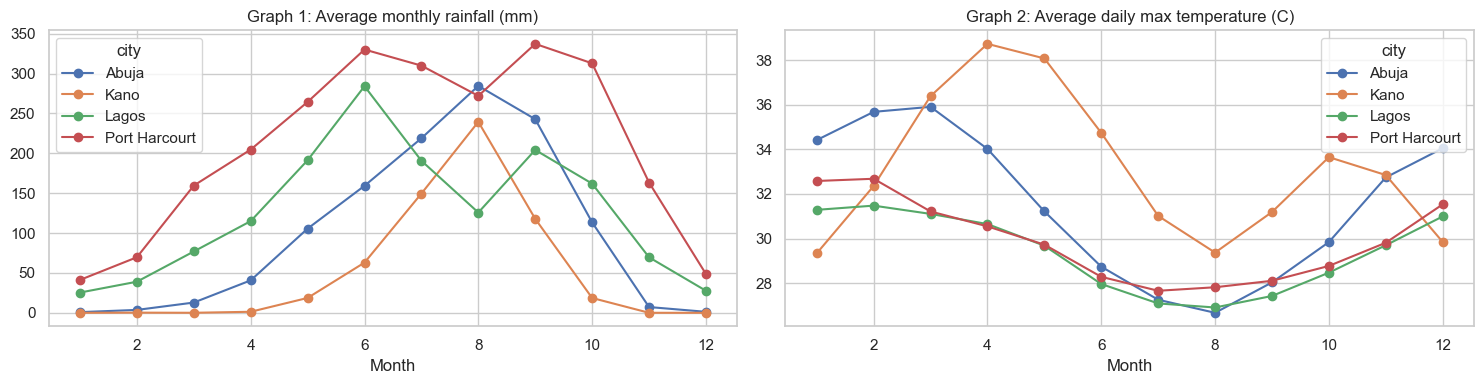

In [5]:
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month

# A rainy day is at least WET_DAY_MM of rainfall
weather["wet"] = (weather["precipitation_sum"] >= WET_DAY_MM).astype(float).where(weather["precipitation_sum"].notna())

# Use complete years when calculating monthly averages
full = weather[weather["year"] < weather["year"].max()]

monthly_rain = (full.groupby(["city", "year", "month"])["precipitation_sum"].sum()
                    .groupby(["city", "month"]).mean().unstack(0))
monthly_tmax = full.groupby(["month", "city"])["temperature_2m_max"].mean().unstack(1)

# Graphs 1 and 2: monthly  rainfalll and maximum temperature
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
monthly_rain.plot(ax=axes[0], marker="o", title="Graph 1: Average monthly rainfall (mm)")
monthly_tmax.plot(ax=axes[1], marker="o", title="Graph 2: Average daily max temperature (C)")
for ax in axes:
    ax.set_xlabel("Month")
plt.tight_layout(); plt.show()

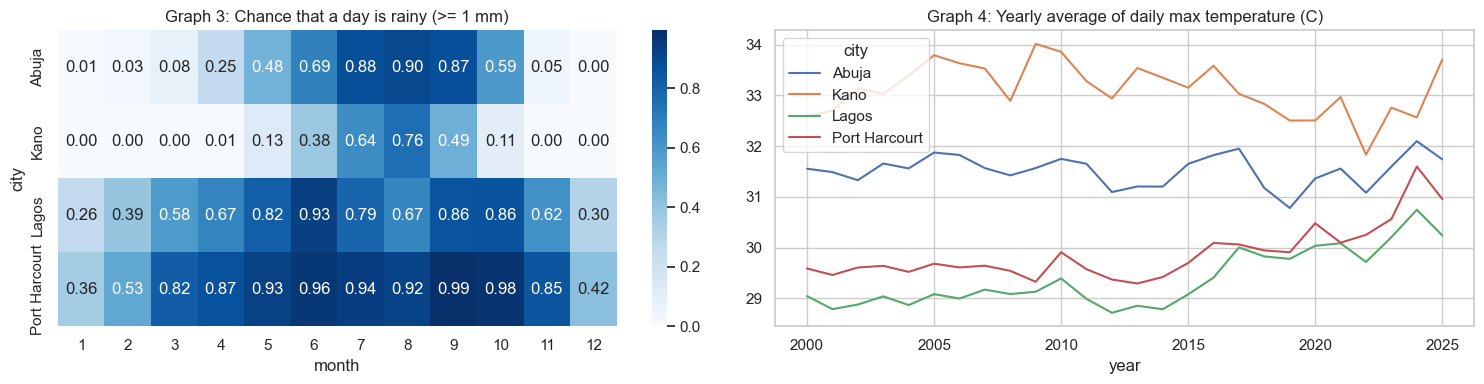

In [6]:
# Graphs 3 and 4: rainy days and yearly remperature trend
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
wet_prob = weather.pivot_table(index="city", columns="month", values="wet", aggfunc="mean")
sns.heatmap(wet_prob, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Graph 3: Chance that a day is rainy (>= 1 mm)")

full.groupby(["year", "city"])["temperature_2m_max"].mean().unstack().plot(ax=axes[1])
axes[1].set_title("Graph 4: Yearly average of daily max temperature (C)")
plt.tight_layout(); plt.show()

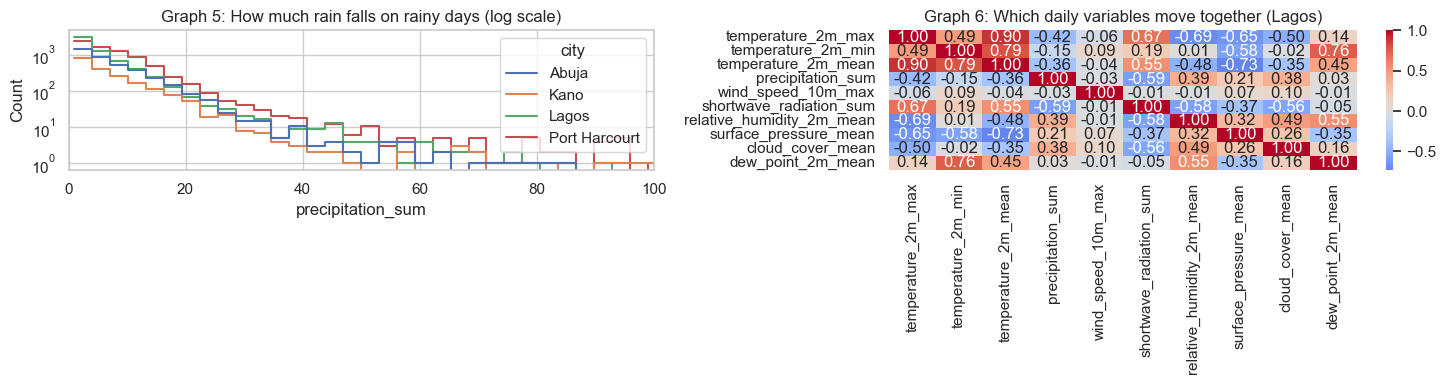

In [7]:
# Graphs 5 and 6: rainfall amount and corellation between variables
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(data=weather[weather["wet"] == 1], x="precipitation_sum", hue="city",
             bins=60, element="step", fill=False, ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_xlim(0, 100)       # log scale because a few days are huge
axes[0].set_title("Graph 5: How much rain falls on rainy days (log scale)")

first_city = list(CITIES)[0]
corr_cols = [c for c in TODAY if c != "rain_sum"]
sns.heatmap(weather[weather["city"] == first_city][corr_cols].corr(), cmap="coolwarm",
            center=0, annot=len(corr_cols) <= 10, fmt=".2f", ax=axes[1])
axes[1].set_title(f"Graph 6: Which daily variables move together ({first_city})")
plt.tight_layout(); plt.show()

### What I noticed

- **The rainy season in each city:**
  - **Abuja:** about May to October, peaking in August (about 285 mm; it rains on about 90% of August days). Almost dry from December to February.
  - **Kano:** a short season from about June to September, peaking in August (about 240 mm). It is essentially dry from November to March.
  - **Lagos:** wet for most of the year, with two peaks around June and September–October. It peaks at about 285 mm in June.
  - **Port Harcourt:** also wet for most of the year, with two peaks around June and September–October. It is the wettest of the four, reaching about 330 mm in June and 337 mm in September.

- **The hottest months in each city:**
  - **Abuja:** February and March, at around 36 °C.
  - **Kano:** April, at about 38.7 °C, with May close behind.
  - **Lagos:** January and February, at around 31–33 °C.
  - **Port Harcourt:** January and February, at around 31–33 °C.
  - August is the coolest month in Lagos, Abuja and Kano, at about 27 °C in Lagos and Abuja and 29 °C in Kano, probably because of the rains.

- **How Kano differs from Lagos and Port Harcourt:**
  - **Kano:** much hotter and drier, with almost no rain from November to March. It also has the biggest seasonal temperature range, from about 29 °C to almost 39 °C.
  - **Lagos:** still gets rain on about 30% of days in December.
  - **Port Harcourt:** still gets rain on about 42% of days in December.
  - Kano also has another cool period in December and January (about 29–30 °C), which could be related to the dry harmattan season, although I haven't tested that.

- **Any temperature trend over the years:**
  - **Lagos:** temperatures rise from about 29 °C to around 30–30.7 °C, mostly since about 2015.
  - **Port Harcourt:** temperatures rise from about 29.5 °C to around 30–31.6 °C, also mostly since about 2015.
  - **Abuja:** looks roughly flat, apart from a rise in 2024.
  - **Kano:** moves between about 32.5 °C and 34 °C, with no clear trend.
  - Overall, this looks like a warming pattern, but it is only four cities of modelled data, so I wouldn't claim a cause. It may also explain why the temperature model runs slightly cool on the test years, since it learned from cooler older years.

- **What the rain-amount chart says about a typical rainy day:**
  - Most rainy days are light, with hundreds to thousands of days in the lowest bins.
  - Heavy days are rare, and a few reach about 80–100 mm.
  - The chart is cut off at 100 mm because I limited the x-axis, so days heavier than that aren't shown.

- **What moves with rain (Graph 6, Lagos):**
  - Rainy days tend to be cooler (correlation with max temperature about **-0.42**), cloudier (**+0.38**), more humid (**+0.39**) and less sunny (**-0.59**).
  - Humidity is also strongly linked to temperature (**-0.69**), which fits with the rain model relying quite a lot on humidity.

## 5. Building features

I turn the daily weather data into the inputs used by the models.

**Targets:**
- `rain_tomorrow`: 1 if tomorrow gets at least 1 mm of rain, otherwise 0
- `tmax_tomorrow`: tomorrow's maximum temperature

The inputs are limited to information available by the end of today:
- today's weather,
- weather from 1, 2, 3 and 7 days ago,
- 3, 7 and 30-day averages,
- number of rainy days in the previous week,
- days since the last rain,
- pressure change,
- time of year,
- and city.

Each rolling feature ends on the current day, so information from tomorrow is not used.

In [8]:
def build_features(g):
    # Build features separately for each city
    g = g.sort_values("date").copy()
    p, tmax = g["precipitation_sum"], g["temperature_2m_max"]

    # Weather lags: 1, 2, 3 and 7 days
    for k in [1, 2, 3, 7]:
        g[f"rain_lag{k}"] = p.shift(k)
        g[f"tmax_lag{k}"] = tmax.shift(k)

    # Rolling averages ending on the current day
    for w in [3, 7, 30]:
        g[f"rain_mean{w}"] = p.rolling(w).mean()
        g[f"tmax_mean{w}"] = tmax.rolling(w).mean()

    # How wet has the last week been, and how long since the last rainy day?
    g["wet_days_7"] = g["wet"].rolling(7).sum()
    last_wet = g["date"].where(g["wet"] == 1).ffill()
    # capped at 60 days, so the dashboard (which only sees the last ~70 days) computes exactly the same number
    g["days_since_rain"] = (g["date"] - last_wet).dt.days.fillna(365).clip(upper=60)

    # Daily pressure change
    if "surface_pressure_mean" in g.columns:
        g["pressure_change"] = g["surface_pressure_mean"].diff()

    # Cyclical time-of-year features
    doy = g["date"].dt.dayofyear
    g["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    g["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # Tomorrow's rain and maximum temperatures
    g["rain_tomorrow"] = g["wet"].shift(-1)
    g["tmax_tomorrow"] = tmax.shift(-1)
    return g

feat = pd.concat([build_features(g) for _, g in weather.groupby("city")], ignore_index=True)

HISTORY = ([c for c in feat.columns if c.startswith(("rain_lag", "tmax_lag", "rain_mean", "tmax_mean"))]
           + ["wet_days_7", "days_since_rain"]
           + (["pressure_change"] if "pressure_change" in feat.columns else []))
SEASON = ["doy_sin", "doy_cos", "month"]

#  Keep city for analysis and create one-hot encoded columns for the models
feat["location"] = feat["city"]
data = pd.get_dummies(feat, columns=["city"], dtype=int)
CITY_COLS = [c for c in data.columns if c.startswith("city_")]

FEATS = TODAY + HISTORY + SEASON + CITY_COLS

# Remove rows without enough history or a next-day target
data = data.dropna(subset=TODAY + HISTORY + ["rain_tomorrow", "tmax_tomorrow"])
data = data.sort_values(["date", "location"]).reset_index(drop=True)

print("Rows:", len(data), "| Number of features:", len(FEATS))
print(FEATS)

Rows: 38592 | Number of features: 34
['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'cloud_cover_mean', 'dew_point_2m_mean', 'rain_lag1', 'tmax_lag1', 'rain_lag2', 'tmax_lag2', 'rain_lag3', 'tmax_lag3', 'rain_lag7', 'tmax_lag7', 'rain_mean3', 'tmax_mean3', 'rain_mean7', 'tmax_mean7', 'rain_mean30', 'tmax_mean30', 'wet_days_7', 'days_since_rain', 'pressure_change', 'doy_sin', 'doy_cos', 'month', 'city_Abuja', 'city_Kano', 'city_Lagos', 'city_Port Harcourt']


## 6. Splitting by time

I use a time-based split instead of a random split because this is a forecasting problem.

- **Train:** 2000–2017
- **Validation:** 2018–2021
- **Test:** 2022–June 2026

The validation period is used for tuning and choosing the rain probability cut-off. The test period is kept separate until th

Rows in train / validation / test: 26184 5844 6564


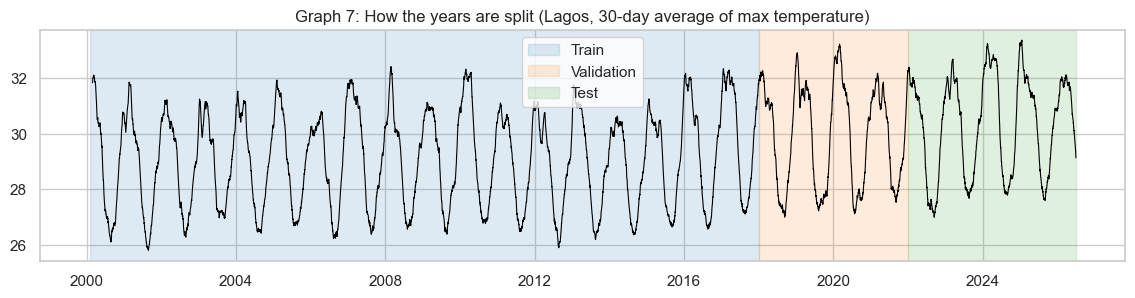


Share of days followed by a rainy day (training years):
location
Abuja            0.434
Kano             0.225
Lagos            0.666
Port Harcourt    0.836
Name: rain_tomorrow, dtype: float64


In [9]:
train = data[data["date"] <= TRAIN_END]
val = data[(data["date"] > TRAIN_END) & (data["date"] <= VAL_END)]
test = data[data["date"] > VAL_END]
print("Rows in train / validation / test:", len(train), len(val), len(test))

# Graph 7: where the split falls on the calendar
first_city = list(CITIES)[0]
line = data[data["location"] == first_city].set_index("date")["temperature_2m_max"].rolling(30).mean()
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(line.index, line.values, lw=0.8, color="black")
ax.axvspan(data["date"].min(), pd.Timestamp(TRAIN_END), alpha=0.15, color="tab:blue", label="Train")
ax.axvspan(pd.Timestamp(TRAIN_END), pd.Timestamp(VAL_END), alpha=0.15, color="tab:orange", label="Validation")
ax.axvspan(pd.Timestamp(VAL_END), data["date"].max(), alpha=0.15, color="tab:green", label="Test")
ax.set_title(f"Graph 7: How the years are split ({first_city}, 30-day average of max temperature)")
ax.legend(); plt.show()

# check the balance between rainy and dry days
print("\nShare of days followed by a rainy day (training years):")
print(train.groupby("location")["rain_tomorrow"].mean().round(3))

## 7. Baselines

Before training the machine learning models, I use simple baselines for comparison.

- **Rain:** tomorrow follows today's rain status, or the usual rain probability for that city and month.
- **Temperature:** tomorrow's maximum temperature is the same as today's, or the usual maximum temperature for that city and month.

For rain, I use ROC-AUC and Brier error alongside the classification metrics. Accuracy alone can be misleading because there are more dry days than rainy days. The probability cut-off is chosen using the validation years and then kept fixed for the test period.

In [10]:
def clf_metrics(y, prob, thr):
    # Rain classification metrics
    pred = (prob >= thr).astype(int)
    return {"AUC": roc_auc_score(y, prob), "F1": f1_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred, zero_division=0),
            "Accuracy": accuracy_score(y, pred), "Brier": brier_score_loss(y, prob)}

def reg_metrics(y, p):
    # Temperature regression metrics
    return {"R2": r2_score(y, p), "MAE": mean_absolute_error(y, p),
            "RMSE": np.sqrt(mean_squared_error(y, p))}

def best_threshold(y, prob):
    # Choose the rain probability cut-off using the validation period
    grid = np.linspace(0.1, 0.9, 81)
    scores = [f1_score(y, (prob >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(scores))])

def climatology(ref, target, col):
    # Calculate city/month averages from the training period
    table = ref.groupby(["location", "month"])[col].mean()
    idx = pd.MultiIndex.from_arrays([target["location"], target["month"]])
    return table.reindex(idx).values

y_val_r = val["rain_tomorrow"].astype(int).values
y_test_r = test["rain_tomorrow"].astype(int).values
y_val_t = val["tmax_tomorrow"].values
y_test_t = test["tmax_tomorrow"].values

# Rain baselines
rain_rows = []
rain_rows.append({"model": "Baseline: same as today", **clf_metrics(y_test_r, test["wet"].values, 0.5)})
clim_val = climatology(train, val, "rain_tomorrow")
clim_test = climatology(train, test, "rain_tomorrow")
thr_clim = best_threshold(y_val_r, clim_val)
rain_rows.append({"model": "Baseline: monthly climatology", "threshold": round(thr_clim, 2),
                  **clf_metrics(y_test_r, clim_test, thr_clim)})

# Temperature baselines
temp_rows = []
temp_rows.append({"model": "Baseline: same as today", **reg_metrics(y_test_t, test["temperature_2m_max"].values)})
temp_rows.append({"model": "Baseline: monthly climatology",
                  **reg_metrics(y_test_t, climatology(train, test, "temperature_2m_max"))})

pd.DataFrame(rain_rows).round(3)

,model,AUC,F1,Precision,Recall,Accuracy,Brier,threshold
0,Baseline: same as today,0.780,0.756,0.757,0.756,0.782,0.218,NaN
1,Baseline: monthly climatology,0.886,0.788,0.713,0.881,0.788,0.146,0.5


## 8. The rain model

I compare three classification models:

- Logistic Regression
- Random Forest
- XGBoost

The models are trained on the training period. I use the validation period to tune the rain probability cut-off, then evaluate the final models on the test period.

In [11]:
def make_clf():
    return {
        "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1,
                                                random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                                 colsample_bytree=0.8, eval_metric="logloss", random_state=RANDOM_STATE),
    }

y_train_r = train["rain_tomorrow"].astype(int).values
clf_fitted, clf_thr, clf_test_prob = {}, {}, {}

for name, m in make_clf().items():
    m.fit(train[FEATS], y_train_r)
    thr = best_threshold(y_val_r, m.predict_proba(val[FEATS])[:, 1])   # cut-off picked on validation years
    prob = m.predict_proba(test[FEATS])[:, 1]
    clf_fitted[name], clf_thr[name], clf_test_prob[name] = m, thr, prob
    rain_rows.append({"model": name, "threshold": round(thr, 2), **clf_metrics(y_test_r, prob, thr)})

pd.DataFrame(rain_rows).round(3)

,model,AUC,F1,Precision,Recall,Accuracy,Brier,threshold
0,Baseline: same as today,0.780,0.756,0.757,0.756,0.782,0.218,NaN
1,Baseline: monthly climatology,0.886,0.788,0.713,0.881,0.788,0.146,0.50
2,Logistic Regression,0.903,0.811,0.727,0.918,0.809,0.126,0.41
3,Random Forest,0.908,0.813,0.750,0.888,0.817,0.123,0.51
4,XGBoost,0.908,0.810,0.751,0.880,0.815,0.124,0.49


In [12]:
#  Tune XGBoost using several parameter combinations
#  Use time-aware cross-validation within the training period
#  Keep the test period completely separate from tuning
param_dist = {"n_estimators": [200, 400, 600], "max_depth": [3, 5, 7],
              "learning_rate": [0.03, 0.05, 0.1], "subsample": [0.7, 0.9],
              "colsample_bytree": [0.7, 0.9], "min_child_weight": [1, 5]}

search_c = RandomizedSearchCV(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                              param_dist, n_iter=12, cv=TimeSeriesSplit(n_splits=4),
                              scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1)
search_c.fit(train[FEATS], y_train_r)
print("Best settings found:", search_c.best_params_)

name = "XGBoost (tuned)"
best_c = search_c.best_estimator_
thr = best_threshold(y_val_r, best_c.predict_proba(val[FEATS])[:, 1])
prob = best_c.predict_proba(test[FEATS])[:, 1]
clf_fitted[name], clf_thr[name], clf_test_prob[name] = best_c, thr, prob
rain_rows.append({"model": name, "threshold": round(thr, 2), **clf_metrics(y_test_r, prob, thr)})

Best settings found: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


## 9. The temperature model

For temperature, the target is tomorrow's maximum temperature rather than a yes/no outcome.

I compare Linear Regression, Random Forest and XGBoost using R², MAE and RMSE.

The same-day temperature is a strong baseline because maximum temperature usually does not change much from one day to the next, so the model needs to improve on that baseline to be useful.

In [13]:
def make_reg():
    return {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1,
                                               random_state=RANDOM_STATE),
        "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                                colsample_bytree=0.8, random_state=RANDOM_STATE),
    }

y_train_t = train["tmax_tomorrow"].values
reg_fitted, reg_test_pred = {}, {}

for name, m in make_reg().items():
    m.fit(train[FEATS], y_train_t)
    pred = m.predict(test[FEATS])
    reg_fitted[name], reg_test_pred[name] = m, pred
    temp_rows.append({"model": name, **reg_metrics(y_test_t, pred)})

pd.DataFrame(temp_rows).round(3)

,model,R2,MAE,RMSE
0,Baseline: same as today,0.798,1.078,1.478
1,Baseline: monthly climatology,0.661,1.510,1.915
2,Linear Regression,0.853,0.967,1.263
3,Random Forest,0.861,0.929,1.227
4,XGBoost,0.863,0.922,1.218


In [14]:
# # Tune XGBoost using MAE as the scoring metric
search_r = RandomizedSearchCV(XGBRegressor(random_state=RANDOM_STATE), param_dist, n_iter=12,
                              cv=TimeSeriesSplit(n_splits=4), scoring="neg_mean_absolute_error",
                              random_state=RANDOM_STATE, n_jobs=-1)
search_r.fit(train[FEATS], y_train_t)
print("Best settings found:", search_r.best_params_)

name = "XGBoost (tuned)"
best_r = search_r.best_estimator_
pred = best_r.predict(test[FEATS])
reg_fitted[name], reg_test_pred[name] = best_r, pred
temp_rows.append({"model": name, **reg_metrics(y_test_t, pred)})

Best settings found: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


## 10. Final models: fix the rain probability and use more years
The first results showed two things I want to fix before the final scoring.

1. **The rain probabilities were over-confident.** When the model said "70%", it rained closer to 60% of the time. Since the dashboard will show a percentage, that matters. I learn a small correction curve (isotonic regression) on the validation years, so that a displayed 70% really means about 70%.
2. **The recent years were missing from training.** The settings were chosen using the training years only. Now that they're chosen, I retrain with the validation years included (2000 to 2021). Lagos and Port Harcourt have warmed since about 2015, so those years matter. The test years stay untouched, so the scores remain honest.
3. **A deployment copy for the dashboard** is trained on every day I have (2000 to June 2026). Nobody can score that one fairly, because it has seen the test years, so every number I report comes from step 2.

In [15]:
# 1) Learn the probability correction on the validation years, using the model that was tuned on the training years.
#    The correction is learned from predictions on days the model had never seen, which is exactly the situation
#    the final model will be in when it faces new days.
raw_val = best_c.predict_proba(val[FEATS])[:, 1]
calibrator = IsotonicRegression(out_of_bounds="clip").fit(raw_val, y_val_r)
thr_cal = best_threshold(y_val_r, calibrator.predict(raw_val))

# 2) Retrain with the settings I already chose, now on train + validation years
trainval = data[data["date"] <= VAL_END]
final_clf = XGBClassifier(**search_c.best_params_, eval_metric="logloss", random_state=RANDOM_STATE)
final_clf.fit(trainval[FEATS], trainval["rain_tomorrow"].astype(int).values)
final_reg = XGBRegressor(**search_r.best_params_, random_state=RANDOM_STATE)
final_reg.fit(trainval[FEATS], trainval["tmax_tomorrow"].values)

raw_test = final_clf.predict_proba(test[FEATS])[:, 1]       # before the correction
cal_test = calibrator.predict(raw_test)                      # after the correction
pred_final = final_reg.predict(test[FEATS])

clf_fitted["XGBoost (final)"], clf_thr["XGBoost (final)"], clf_test_prob["XGBoost (final)"] = final_clf, thr_cal, cal_test
reg_fitted["XGBoost (final)"], reg_test_pred["XGBoost (final)"] = final_reg, pred_final

thr_tuned = clf_thr["XGBoost (tuned)"]
rain_rows.append({"model": "XGBoost (final, uncalibrated)", "threshold": round(thr_tuned, 2),
                  **clf_metrics(y_test_r, raw_test, thr_tuned)})
rain_rows.append({"model": "XGBoost (final)", "threshold": round(thr_cal, 2),
                  **clf_metrics(y_test_r, cal_test, thr_cal)})
temp_rows.append({"model": "XGBoost (final)", **reg_metrics(y_test_t, pred_final)})

# 3) Deployment copies for the dashboard: same settings, trained on every day we have.
#    These are NOT scored (they have seen the test years). All reported numbers come from the models above.
deploy_clf = XGBClassifier(**search_c.best_params_, eval_metric="logloss", random_state=RANDOM_STATE)
deploy_clf.fit(data[FEATS], data["rain_tomorrow"].astype(int).values)
deploy_reg = XGBRegressor(**search_r.best_params_, random_state=RANDOM_STATE)
deploy_reg.fit(data[FEATS], data["tmax_tomorrow"].values)

print("Rain cut-off after calibration:", round(thr_cal, 2))
print("Brier score before vs after calibration (lower is better):",
      round(brier_score_loss(y_test_r, raw_test), 4), "->", round(brier_score_loss(y_test_r, cal_test), 4))

Rain cut-off after calibration: 0.41
Brier score before vs after calibration (lower is better): 0.1211 -> 0.1209


## 11. Evaluation on the test years

The final evaluation uses the test period from 2022 to June 2026. These years were not used for training or tuning.

For rain, I compare the models using ROC-AUC, Brier error and classification accuracy. I also check calibration and performance by city.

For temperature, I compare MAE, R² and the size of the prediction errors across cities and months.

In [16]:
print("WILL IT RAIN TOMORROW? (test years)")
display(pd.DataFrame(rain_rows).set_index("model").round(3))
print("\nHOW HOT TOMORROW? (test years)")
display(pd.DataFrame(temp_rows).set_index("model").round(3))

WILL IT RAIN TOMORROW? (test years)


,AUC,F1,Precision,Recall,Accuracy,Brier,threshold
model,,,,,,,
Baseline: same as today,0.780,0.756,0.757,0.756,0.782,0.218,NaN
Baseline: monthly climatology,0.886,0.788,0.713,0.881,0.788,0.146,0.50
Logistic Regression,0.903,0.811,0.727,0.918,0.809,0.126,0.41
Random Forest,0.908,0.813,0.750,0.888,0.817,0.123,0.51
XGBoost,0.908,0.810,0.751,0.880,0.815,0.124,0.49
XGBoost (tuned),0.909,0.810,0.761,0.866,0.818,0.123,0.54
"XGBoost (final, uncalibrated)",0.910,0.808,0.773,0.845,0.820,0.121,0.54
XGBoost (final),0.910,0.805,0.774,0.839,0.818,0.121,0.41



HOW HOT TOMORROW? (test years)


,R2,MAE,RMSE
model,,,
Baseline: same as today,0.798,1.078,1.478
Baseline: monthly climatology,0.661,1.510,1.915
Linear Regression,0.853,0.967,1.263
Random Forest,0.861,0.929,1.227
XGBoost,0.863,0.922,1.218
XGBoost (tuned),0.865,0.912,1.209
XGBoost (final),0.865,0.911,1.206


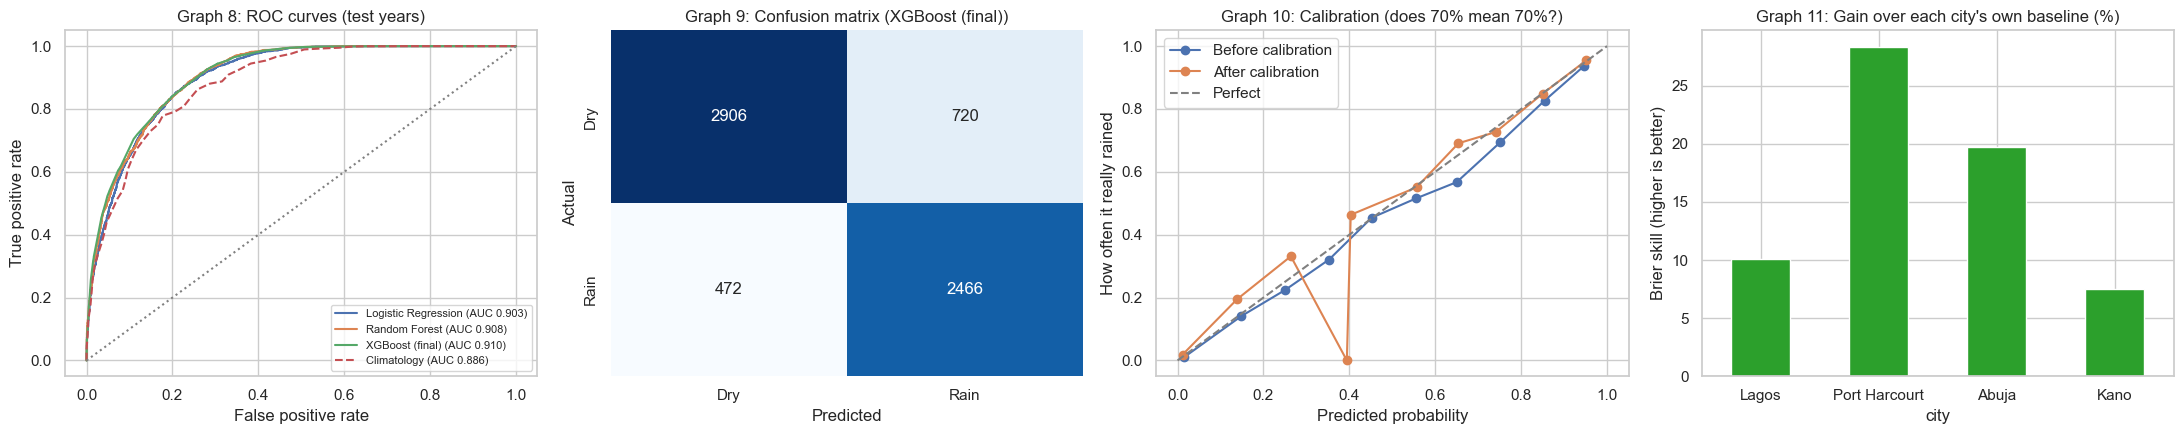

,AUC model,AUC climatology,Brier skill vs climatology
city,,,
Lagos,0.788,0.738,0.101
Port Harcourt,0.894,0.867,0.283
Abuja,0.926,0.904,0.197
Kano,0.926,0.915,0.075


In [17]:
best_name = "XGBoost (final)"
prob_b, thr_b = clf_test_prob[best_name], clf_thr[best_name]

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

# Graph 8: ROC curves 
for name in ["Logistic Regression", "Random Forest", best_name]:
    fpr, tpr, _ = roc_curve(y_test_r, clf_test_prob[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test_r, clf_test_prob[name]):.3f})")
fpr, tpr, _ = roc_curve(y_test_r, clim_test)
axes[0].plot(fpr, tpr, "--", label=f"Climatology (AUC {roc_auc_score(y_test_r, clim_test):.3f})")
axes[0].plot([0, 1], [0, 1], ":", color="grey")
axes[0].set_title("Graph 8: ROC curves (test years)"); axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate"); axes[0].legend(fontsize=8)

# Graph 9: confusion matrix
cm = confusion_matrix(y_test_r, (prob_b >= thr_b).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Dry", "Rain"], yticklabels=["Dry", "Rain"])
axes[1].set_title(f"Graph 9: Confusion matrix ({best_name})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

# Graph 10: rain probability calibration
for label, p in [("Before calibration", raw_test), ("After calibration", cal_test)]:
    frac, mean_pred = calibration_curve(y_test_r, p, n_bins=10)
    axes[2].plot(mean_pred, frac, marker="o", label=label)
axes[2].plot([0, 1], [0, 1], "--", color="grey", label="Perfect")
axes[2].set_title("Graph 10: Calibration (does 70% mean 70%?)")
axes[2].set_xlabel("Predicted probability"); axes[2].set_ylabel("How often it really rained"); axes[2].legend()

# Graph 11:  rain model performance by city
# (F1 isn't comparable across cities because it depends on how often it rains there, so I use the Brier skill:
#  1 minus model error / baseline error. Above zero means the model beats that city's own monthly average.)
rows = []
for c in CITIES:
    mask = (test["location"] == c).values
    b_model = brier_score_loss(y_test_r[mask], prob_b[mask])
    b_clim = brier_score_loss(y_test_r[mask], clim_test[mask])
    rows.append({"city": c,
                 "AUC model": roc_auc_score(y_test_r[mask], prob_b[mask]),
                 "AUC climatology": roc_auc_score(y_test_r[mask], clim_test[mask]),
                 "Brier skill vs climatology": 1 - b_model / b_clim})
by_city = pd.DataFrame(rows).set_index("city")
(by_city["Brier skill vs climatology"] * 100).plot.bar(ax=axes[3], rot=0, color="tab:green")
axes[3].axhline(0, color="black", lw=0.8)
axes[3].set_title("Graph 11: Gain over each city's own baseline (%)")
axes[3].set_ylabel("Brier skill (higher is better)")
plt.tight_layout(); plt.show()
by_city.round(3)

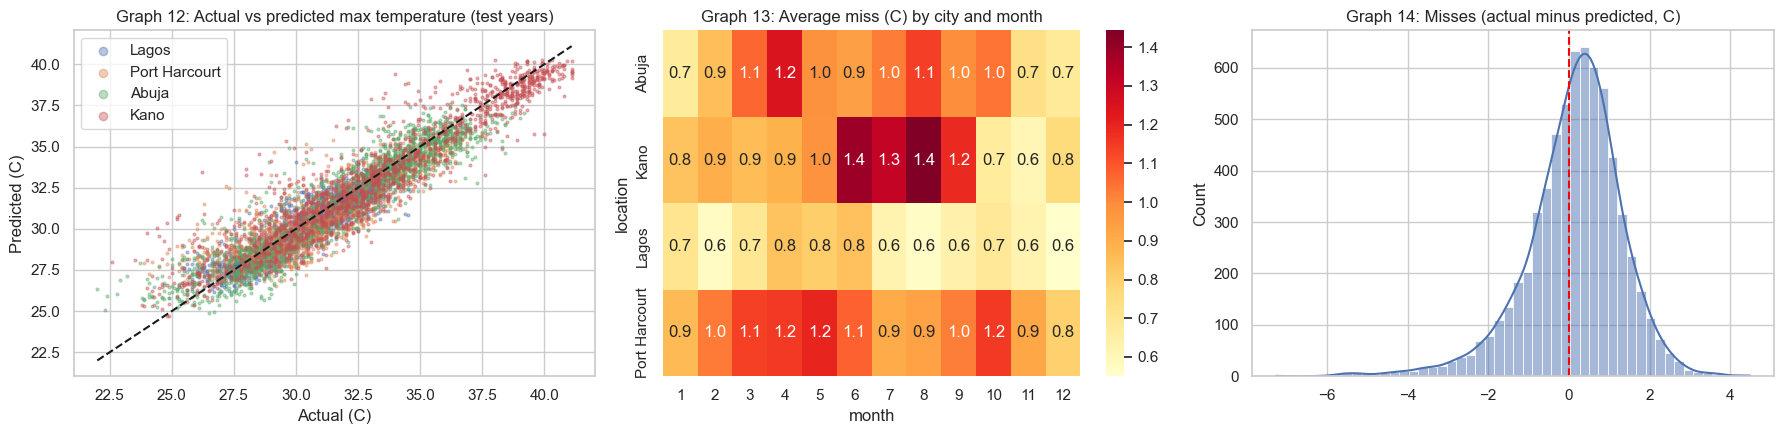

In [18]:
pred_b = reg_test_pred["XGBoost (final)"]
resid = y_test_t - pred_b            # positive = the model guessed too cool

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Graph 12: predicted versus actual temperature
for c in CITIES:
    mask = (test["location"] == c).values
    axes[0].scatter(y_test_t[mask], pred_b[mask], s=4, alpha=0.4, label=c)
lims = [y_test_t.min(), y_test_t.max()]
axes[0].plot(lims, lims, "k--")
axes[0].set_title("Graph 12: Actual vs predicted max temperature (test years)")
axes[0].set_xlabel("Actual (C)"); axes[0].set_ylabel("Predicted (C)"); axes[0].legend(markerscale=3)

# Graph 13: temperature error by city and month
err = pd.DataFrame({"location": test["location"].values, "month": test["month"].values, "abs_err": np.abs(resid)})
sns.heatmap(err.pivot_table(index="location", columns="month", values="abs_err", aggfunc="mean"),
            annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Graph 13: Average miss (C) by city and month")

# Graph 14: distribution of temperature residuals
sns.histplot(resid, bins=50, kde=True, ax=axes[2])
axes[2].axvline(0, color="red", ls="--")
axes[2].set_title("Graph 14: Misses (actual minus predicted, C)")
plt.tight_layout(); plt.show()

## 12. Feature importance

I use feature importance from the tuned XGBoost models to see which inputs contribute most to the predictions.

For the rain model, I look for the importance of recent rainfall and other recent weather variables. For temperature, I compare the importance of today's and recent temperatures with the other features.

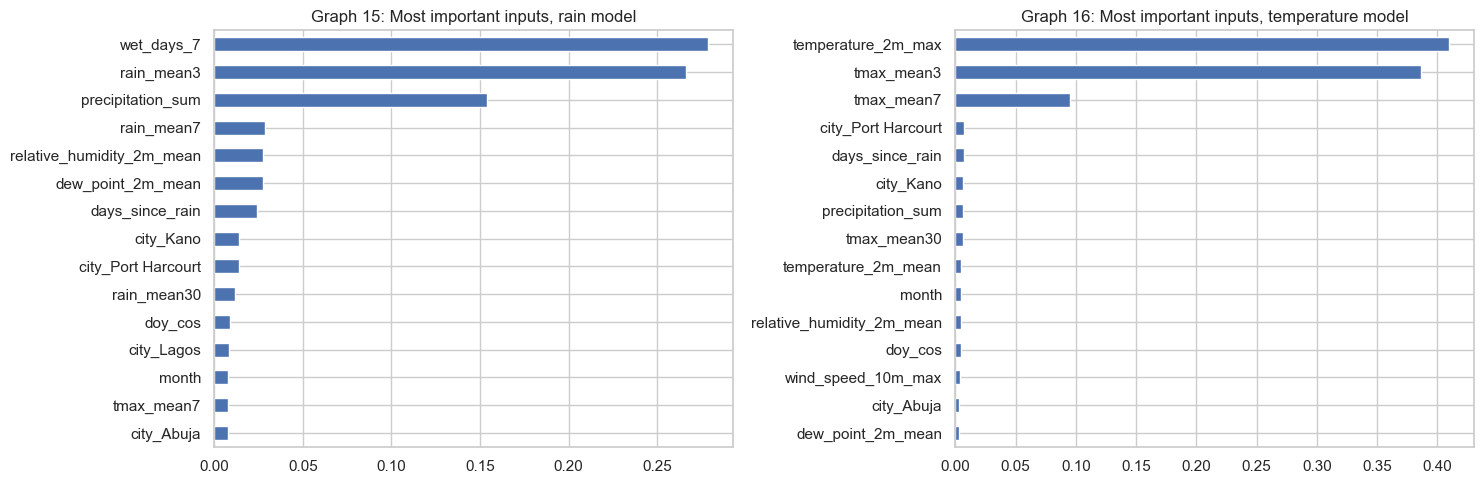

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
pd.Series(clf_fitted["XGBoost (final)"].feature_importances_, index=FEATS).nlargest(15).sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Graph 15: Most important inputs, rain model")
pd.Series(reg_fitted["XGBoost (final)"].feature_importances_, index=FEATS).nlargest(15).sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Graph 16: Most important inputs, temperature model")
plt.tight_layout(); plt.show()

## 13. Which information actually helps?
This is the most interesting experiment. I train the same model four times, each time with a bit more information, and score all of them on the same test years:

- **A:** only today's weather
- **B:** plus the recent past (lags, averages, days since rain)
- **C:** plus the time of year
- **D:** plus which city it is

If a step improves the scores, that information matters. If it doesn't, I can say so too.

,Rain AUC,Rain F1,Temp MAE (C)
features,,,
A: today only,0.897,0.805,1.010
B: + recent history,0.905,0.807,0.926
C: + season,0.907,0.811,0.925
D: + city,0.908,0.810,0.922


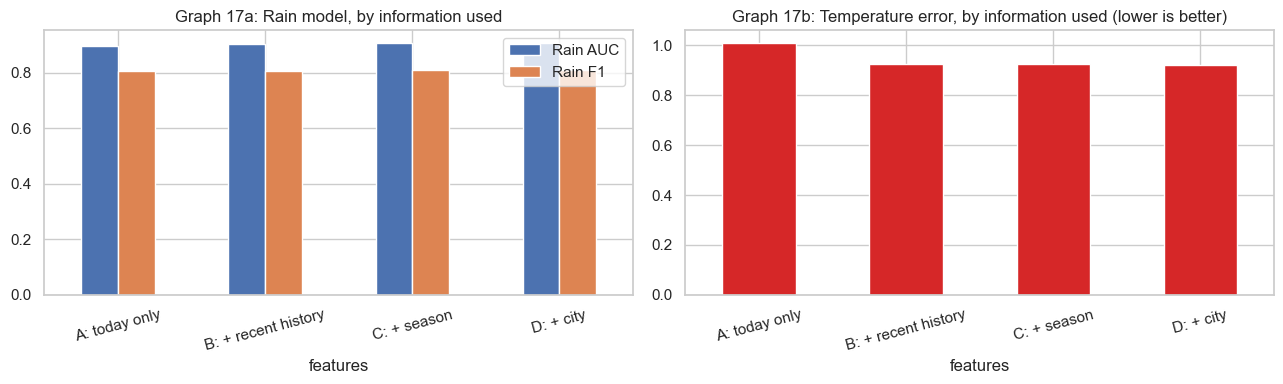

In [20]:
groups = {
    "A: today only": TODAY,
    "B: + recent history": TODAY + HISTORY,
    "C: + season": TODAY + HISTORY + SEASON,
    "D: + city": FEATS,
}

rows = []
for gname, cols in groups.items():
    c = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                      colsample_bytree=0.8, eval_metric="logloss", random_state=RANDOM_STATE)
    c.fit(train[cols], y_train_r)
    pv, pt = c.predict_proba(val[cols])[:, 1], c.predict_proba(test[cols])[:, 1]
    r = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                     colsample_bytree=0.8, random_state=RANDOM_STATE)
    r.fit(train[cols], y_train_t)
    rows.append({"features": gname,
                 "Rain AUC": roc_auc_score(y_test_r, pt),
                 "Rain F1": f1_score(y_test_r, (pt >= best_threshold(y_val_r, pv)).astype(int)),
                 "Temp MAE (C)": mean_absolute_error(y_test_t, r.predict(test[cols]))})

info = pd.DataFrame(rows).set_index("features")
display(info.round(3))

# Graph 17: effect of adding feature groups on model performance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
info[["Rain AUC", "Rain F1"]].plot.bar(ax=axes[0], rot=15)
axes[0].set_title("Graph 17a: Rain model, by information used")
info["Temp MAE (C)"].plot.bar(ax=axes[1], rot=15, color="tab:red")
axes[1].set_title("Graph 17b: Temperature error, by information used (lower is better)")
plt.tight_layout(); plt.show()

## 14. Saving the model and dashboard files
Three files go to the dashboard:
- `rain_model.joblib`: the deployment rain model, the probability correction, the rain cut-off and the list of inputs
- `temp_model.joblib`: the deployment temperature model
- `typical_values.csv`: the usual value of every input for each city and month (the dashboard's what-if mode needs this to fill in the inputs the user doesn't set)


In [21]:
# "month" is both a grouping key and an input, so it is left out of the averaged columns
typical = data.groupby(["location", "month"])[[c for c in FEATS if c != "month"]].mean().reset_index()
typical.to_csv("typical_values.csv", index=False)

joblib.dump({"model": deploy_clf, "calibrator": calibrator, "features": FEATS, "today_vars": TODAY,
             "threshold": float(thr_cal), "wet_day_mm": WET_DAY_MM, "cities": CITIES,
             "data_end": str(data["date"].max().date())}, "rain_model.joblib")
joblib.dump({"model": deploy_reg, "features": FEATS, "today_vars": TODAY, "cities": CITIES},
            "temp_model.joblib")
print("Saved rain_model.joblib, temp_model.joblib and typical_values.csv")
print("Evaluation numbers come from models trained up to", VAL_END,
      "| the deployment models use data up to", data["date"].max().date())

Saved rain_model.joblib, temp_model.joblib and typical_values.csv
Evaluation numbers come from models trained up to 2021-12-31 | the deployment models use data up to 2026-06-29
